<h1><center><b>💻 Practice 12:</b> </br> Structure-Preserving GRL</center></h1>

# 1. RolX: Structural Role Extraction & Mining in Large Graphs

## 1.1. Helper class

In [ ]:
import pandas as pd
import numpy as np
import itertools as it
from collections import defaultdict
from typing import List, Optional, Dict, Set, Iterator, Tuple

from sklearn.decomposition import NMF
from scipy.spatial.distance import pdist

def vertical_log_binning(arr, frac: float = 0.5):
    if not 0 < frac < 1:
        raise ValueError('frac must be in (0, 1)')
    arr = np.asarray(arr).flatten()
    arr_len = len(arr)
    binned = np.zeros(arr_len, dtype=int)
    arr_uniq, counts = np.unique(arr, return_counts=True)
    counts = np.cumsum(counts)
    binned_len = 0
    unbinned_len = arr_len
    bin_min = -np.inf
    
    for bin_val in range(arr_len):
        bin_size = max(int(frac * unbinned_len), 1)
        u_idx = np.searchsorted(counts, binned_len + bin_size)
        bin_max = arr_uniq[u_idx]
        arr_idx = np.logical_and(arr > bin_min, arr <= bin_max)
        binned[arr_idx] = bin_val
        binned_len += np.sum(arr_idx)
        unbinned_len = arr_len - binned_len
        bin_min = bin_max
        if unbinned_len == 0:
            break
    return binned

class AdjacencyDictGraph:
    def __init__(self, G):
        self.adj_dict = self._build_adjacency_dict(G)
    
    def _build_adjacency_dict(self, G):
        adj = defaultdict(set)
        for u, v in G.edges():
            adj[u].add(v)
            adj[v].add(u)
        return dict(adj)
    
    def get_nodes(self): return list(self.adj_dict.keys())
    def get_neighbors(self, node): return self.adj_dict.get(node, set())
    def get_num_edges(self): 
        return sum(len(neighs) for neighs in self.adj_dict.values()) // 2

class AdjacencyDictGraphForFeatures:
    def __init__(self, edges):
        self.adj_dict = defaultdict(set)
        for a, b in edges:
            self.adj_dict[a].add(b)
            self.adj_dict[b].add(a)
    
    def get_connected_components(self):
        visited = set()
        for node in list(self.adj_dict):
            if node not in visited:
                component = self._dfs(node)
                visited.update(component)
                yield component
    
    def _dfs(self, node):
        visited = set()
        stack = [node]
        while stack:
            cur = stack.pop()
            if cur in visited: continue
            visited.add(cur)
            stack.extend(self.adj_dict[cur] - visited)
        return visited

class FeaturePruner:
    def __init__(self, generation_dict: Dict, feature_group_thresh: int):
        self._generation_dict = generation_dict
        self._feature_group_thresh = feature_group_thresh
    
    def prune_features(self, features: pd.DataFrame) -> List[str]:
        features_to_drop = []
        for group in self._group_features(features):
            if len(group) == 1: continue
            oldest = self._get_oldest_feature(group)
            features_to_drop.extend(group - {oldest})
        return features_to_drop
    
    def _group_features(self, features: pd.DataFrame):
        binned = features.apply(vertical_log_binning)
        dists = pdist(binned.T, metric='chebychev')
        nodes = binned.columns
        edges = it.compress(it.combinations(nodes, 2), dists <= self._feature_group_thresh)
        return AdjacencyDictGraphForFeatures(edges).get_connected_components()
    
    def _get_oldest_feature(self, feature_names: Set) -> str:
        for gen in range(len(self._generation_dict) + 1):
            if gen in self._generation_dict:
                cur = feature_names & set(self._generation_dict[gen].keys())
                if cur:
                    return sorted(cur)[0]
        return sorted(feature_names)[0]

## 1.2. Role Extractor

In [ ]:
class RoleExtractor:
    def __init__(self, n_roles: Optional[int] = None, n_role_range: Tuple[int,int] = (2, 8)):
        self.n_roles = n_roles
        self.min_roles, self.max_roles = n_role_range
        self.node_role_factor = None
        self.role_feature_factor = None
    
    def extract_roles(self, features: pd.DataFrame):
        X = features.values.astype(float)
        X = np.maximum(X, 0)
        
        if X.shape[1] == 0:
            raise ValueError("No features available!")
        
        if self.n_roles:
            G, F = self._get_nmf_factors(X, self.n_roles)
        else:
            G, F = self._select_best_model(X)
        
        role_names = [f'Role_{i}' for i in range(G.shape[1])]
        self.node_role_factor = pd.DataFrame(G, index=features.index, columns=role_names)
        self.role_feature_factor = pd.DataFrame(F, index=role_names, columns=features.columns)
        
        return self.node_role_factor, self.role_feature_factor
    
    def _get_nmf_factors(self, X: np.ndarray, n_roles: int):
        """Fixed NMF with compatible init and solver"""
        model = NMF(
            n_components=n_roles,
            init='nndsvda', 
            solver='mu',
            max_iter=1000,
            random_state=42,
            tol=1e-4
        )
        G = model.fit_transform(X)
        F = model.components_
        return G, F
    
    def _select_best_model(self, X: np.ndarray):
        best_cost = np.inf
        best_G, best_F = None, None
        best_k = 2
        
        for k in range(self.min_roles, self.max_roles + 1):
            try:
                G, F = self._get_nmf_factors(X, k)
                cost = self._compute_mdl_cost(X, G, F)
                if cost < best_cost:
                    best_cost = cost
                    best_G, best_F = G, F
                    best_k = k
            except Exception:
                continue
        
        if best_G is None:
            print("MDL selection failed → Using 2 roles as fallback")
            best_G, best_F = self._get_nmf_factors(X, 2)
            best_k = 2
        else:
            print(f"✅ Selected {best_k} roles by MDL")
        
        return best_G, best_F
    
    @staticmethod
    def _compute_mdl_cost(V, G, F):
        error = np.linalg.norm(V - G @ F, ord='fro') ** 2
        return error + 0.001 * (G.size + F.size)

## 1.3. Recursive Feature Extractor

In [ ]:
class RecursiveFeatureExtractor:
    default_aggs = ['sum', 'mean']
    
    def __init__(self, G, max_generations: int = 6, aggs: Optional[List] = None):
        self.graph = AdjacencyDictGraph(G)
        if self.graph.get_num_edges() == 0:
            raise ValueError("Graph must have at least one edge.")
        
        self.max_generations = max_generations
        self.aggs = aggs if aggs is not None else self.default_aggs
        
        self._features = pd.DataFrame()                    # Main feature matrix
        self._final_features: Dict[int, pd.DataFrame] = {} # Store per generation
        self.generation_count = 0
        self.role_extractor = RoleExtractor()
    
    def extract_features(self) -> pd.DataFrame:
        if not self._features.empty:
            return self._features
        
        # Generation 0
        features = self._get_neighborhood_features()
        self._update(features)
        
        for gen in range(1, self.max_generations + 1):
            self.generation_count = gen
            features = self._get_next_generation_features()
            self._update(features)
            if not self._final_features.get(gen) is not None and len(self._final_features.get(gen, pd.DataFrame()).columns) == 0:
                print(f"Early stopping at generation {gen}")
                break
                
        return self._features.copy()
    
    def _get_neighborhood_features(self):
        nodes = self.graph.get_nodes()
        degrees = {node: len(self.graph.get_neighbors(node)) for node in nodes}
        return pd.DataFrame.from_dict(degrees, orient='index', columns=['degree'])
    
    def _get_next_generation_features(self):
        prev_cols = list(self._final_features[self.generation_count - 1].columns)
        data = {}
        for node in self.graph.get_nodes():
            neighbors = list(self.graph.get_neighbors(node))
            if not neighbors:
                agg_dict = {f"{col}_{agg}": 0.0 for col in prev_cols for agg in self.aggs}
            else:
                neigh_df = self._features.loc[neighbors, prev_cols]
                agg_df = neigh_df.agg(self.aggs)
                agg_dict = self._agg_to_dict(agg_df)
            data[node] = agg_dict
        return pd.DataFrame.from_dict(data, orient='index')
    
    def _update(self, new_features: pd.DataFrame):
        self._features = pd.concat([self._features, new_features], axis=1).fillna(0)
        
        pruner = FeaturePruner(self._final_features, self.generation_count)
        to_drop = pruner.prune_features(self._features)
        self._features = self._features.drop(columns=to_drop, errors='ignore')
        
        kept = new_features.columns.difference(to_drop)
        if len(kept) > 0:
            self._final_features[self.generation_count] = self._features[kept].copy()
    
    @staticmethod
    def _agg_to_dict(agg_df):
        if isinstance(agg_df, pd.Series):
            agg_df = agg_df.to_frame().T
        result = {}
        for agg_name, row in agg_df.iterrows():
            for col, val in row.items():
                result[f"{col}_{agg_name}"] = val
        return result
    
    def extract_roles(self, n_roles: Optional[int] = None):
        if self._features.empty:
            self.extract_features()
        return self.role_extractor.extract_roles(self._features)

## 1.4. Test on Katate Club dataset

In [ ]:
import networkx as nx
G = nx.karate_club_graph()

extractor = RecursiveFeatureExtractor(G, max_generations=6)
features = extractor.extract_features()
print("Features shape:", features.shape)

node_roles, role_features = extractor.extract_roles()
print("Roles shape:", node_roles.shape)
print("\nRole distribution:")
print(node_roles.idxmax(axis=1).value_counts())

Early stopping at generation 2
Features shape: (34, 2)
✅ Selected 2 roles by MDL
Roles shape: (34, 2)

Role distribution:
Role_1    29
Role_0     5
Name: count, dtype: int64


## 1.5. Visualization

✅ Selected 2 roles by MDL


/tmp/ipykernel_15557/405302879.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=role_counts.index, y=role_counts.values, palette=role_colors)


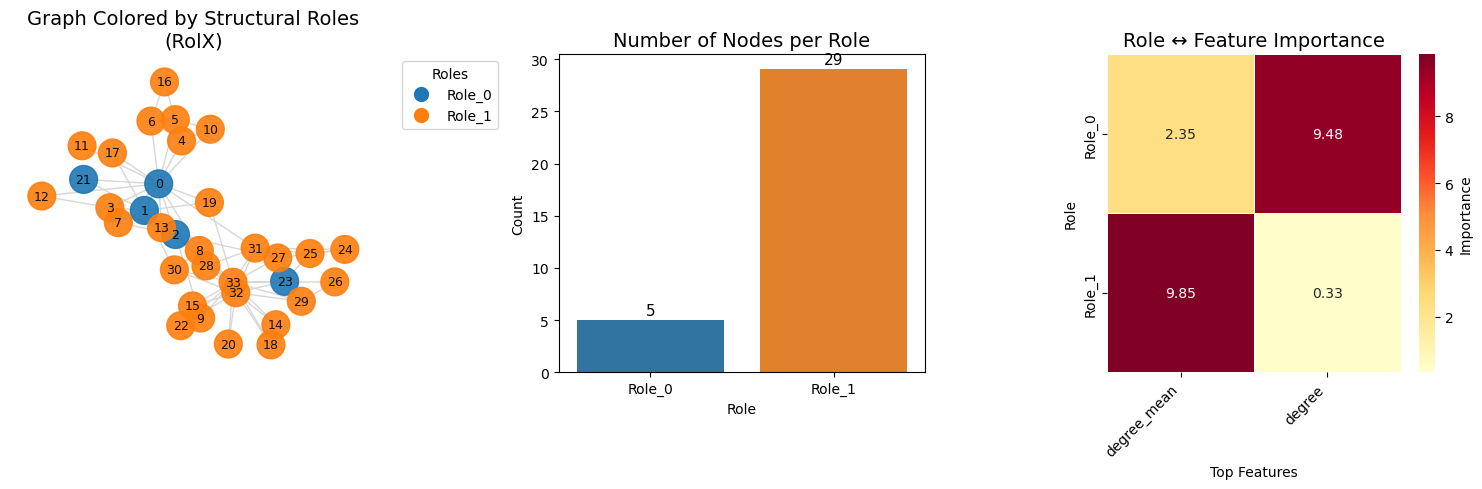

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

def visualize_rolx_results(extractor, G, node_roles, top_k_features=8):
    plt.figure(figsize=(15, 5))
    
    dominant_role = node_roles.idxmax(axis=1)
    role_colors = sns.color_palette("tab10", n_colors=node_roles.shape[1])
    
    # Graph with Roles 
    plt.subplot(1, 3, 1)
    pos = nx.spring_layout(G, seed=42)
    
    nx.draw(G, pos, 
            node_color=[role_colors[int(role.split('_')[1])] for role in dominant_role],
            node_size=400,
            with_labels=True,
            font_size=9,
            edge_color='lightgray',
            alpha=0.9)
    
    plt.title("Graph Colored by Structural Roles\n(RolX)", fontsize=14)
    
    # Legend
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                 markerfacecolor=role_colors[i], markersize=12, label=role) 
                      for i, role in enumerate(node_roles.columns)]
    plt.legend(handles=legend_elements, title="Roles", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Role Distribution 
    plt.subplot(1, 3, 2)
    role_counts = dominant_role.value_counts().sort_index()
    sns.barplot(x=role_counts.index, y=role_counts.values, palette=role_colors)
    plt.title("Number of Nodes per Role", fontsize=14)
    plt.xlabel("Role")
    plt.ylabel("Count")
    for i, count in enumerate(role_counts.values):
        plt.text(i, count + 0.5, str(count), ha='center', fontsize=11)
    
    # Role-Feature Importance
    plt.subplot(1, 3, 3)
    role_feat = extractor.role_extractor.role_feature_factor
    
    # Chỉ lấy top features để heatmap dễ nhìn
    top_features = role_feat.abs().mean().nlargest(top_k_features).index
    sns.heatmap(role_feat[top_features], cmap="YlOrRd", annot=True, 
                fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Importance'})
    plt.title("Role ↔ Feature Importance", fontsize=14)
    plt.ylabel("Role")
    plt.xlabel("Top Features")
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    

node_roles, _ = extractor.extract_roles()

visualize_rolx_results(extractor, G, node_roles)

# 2. Struc2Vec: Learning Node Representations from Structural Identity

## 2.0. Sampling method for Negative Samples

In [27]:
import numpy as np

# Create an alias table from a given probability distribution. It's used for efficient sampling of negative samples
def create_alias_table(area_ratio):
    """

    :param area_ratio: sum(area_ratio)=1
    :return: accept,alias
    """
    l = len(area_ratio)
    accept, alias = [0] * l, [0] * l
    small, large = [], []
    area_ratio_ = np.array(area_ratio) * l
    for i, prob in enumerate(area_ratio_):
        if prob < 1.0:
            small.append(i)
        else:
            large.append(i)

    while small and large:
        small_idx, large_idx = small.pop(), large.pop()
        accept[small_idx] = area_ratio_[small_idx]
        alias[small_idx] = large_idx
        area_ratio_[large_idx] = area_ratio_[large_idx] - \
                                 (1 - area_ratio_[small_idx])
        if area_ratio_[large_idx] < 1.0:
            small.append(large_idx)
        else:
            large.append(large_idx)

    while large:
        large_idx = large.pop()
        accept[large_idx] = 1
    while small:
        small_idx = small.pop()
        accept[small_idx] = 1

    return accept, alias

# This function performs alias sampling
def alias_sample(accept, alias):
    """

    :param accept:
    :param alias:
    :return: sample index
    """
    N = len(accept)
    i = int(np.random.random() * N) # Selects an index i based on a uniform random variable
    r = np.random.random()
    # Returns the selected index if a secondary random check is below the accept threshold; otherwise, returns the alias index
    if r < accept[i]:
        return i
    else:
        return alias[i]

## 2.1. Define functions

In [28]:
"""
Divide a dictionary of vertices into chunks for parallel processing

It takes the vertices dictionary and the number of workers as input

Then, it iterates through the vertices, creating chunks of vertices based on the batch size

Finally, it returns a list of partitions containing these chunks
"""
def partition_dict(vertices, workers):
    batch_size = (len(vertices) - 1) // workers + 1
    part_list = []
    part = []
    count = 0
    for v1, nbs in vertices.items():
        part.append((v1, nbs))
        count += 1
        if count % batch_size == 0:
            part_list.append(part)
            part = []
    if len(part) > 0:
        part_list.append(part)
    return part_list

# Distribute a number into almost equal parts for workers
def partition_num(num, workers):
    if num % workers == 0:
        return [num // workers] * workers
    else:
        return [num // workers] * workers + [num % workers]

## 2.2. Create BiasedWalker: simulating biased random walks on the graph

In [36]:
from joblib import Parallel, delayed

# Generates biased random walks on a graph. It initializes with the index-to-node mapping and a temporary path for storing intermediate results
class BiasedWalker:
    def __init__(self, idx2node, temp_path):

        self.idx2node = idx2node
        self.idx = list(range(len(self.idx2node)))
        self.temp_path = temp_path
        pass

    # Generates random walks on the graph. It takes parameters such as the number of walks, walk length.
    def simulate_walks(self, num_walks, walk_length, stay_prob=0.3, workers=1, verbose=0):

        layers_adj = pd.read_pickle(self.temp_path + 'layers_adj.pkl')
        layers_alias = pd.read_pickle(self.temp_path + 'layers_alias.pkl')
        layers_accept = pd.read_pickle(self.temp_path + 'layers_accept.pkl')
        gamma = pd.read_pickle(self.temp_path + 'gamma.pkl')

        nodes = self.idx  # list(self.g.nodes())

        # Parallelizes the generation of random walks
        results = Parallel(n_jobs=workers, verbose=verbose, )(
            delayed(self._simulate_walks)(nodes, num, walk_length, stay_prob, layers_adj, layers_accept, layers_alias,
                                          gamma) for num in
            partition_num(num_walks, workers))
        # Each worker generates walks for a portion of the walks, and the results are combined
        walks = list(itertools.chain(*results))
        return walks

    # Perform the actual random walk generation. It shuffles the nodes and iterates over them to simulate walks
    def _simulate_walks(self, nodes, num_walks, walk_length, stay_prob, layers_adj, layers_accept, layers_alias, gamma):
        walks = []
        for _ in range(num_walks):
            random.shuffle(nodes)
            for v in nodes:
                walks.append(self._exec_random_walk(layers_adj, layers_accept, layers_alias,
                                                    v, walk_length, gamma, stay_prob))
        return walks

    # Execute a single random walk. It handles both staying in the same layer and moving to a different layer based on probabilities
    def _exec_random_walk(self, graphs, layers_accept, layers_alias, v, walk_length, gamma, stay_prob=0.3):
        initialLayer = 0
        layer = initialLayer

        path = []
        path.append(self.idx2node[v])

        while len(path) < walk_length:
            r = random.random()
            if (r < stay_prob):  # same layer
                v = chooseNeighbor(v, graphs, layers_alias,
                                   layers_accept, layer)
                path.append(self.idx2node[v])
            else:  # different layer
                r = random.random()
                try:
                    x = math.log(gamma[layer][v] + math.e)
                    p_moveup = (x / (x + 1))
                except:
                    print(layer, v)
                    raise ValueError()

                if (r > p_moveup):
                    if (layer > initialLayer):
                        layer = layer - 1
                else:
                    if ((layer + 1) in graphs and v in graphs[layer + 1]):
                        layer = layer + 1

        return path


def chooseNeighbor(v, graphs, layers_alias, layers_accept, layer):
    v_list = graphs[layer][v]

    idx = alias_sample(layers_accept[layer][v], layers_alias[layer][v])
    v = v_list[idx]

    return v

## 2.3. Create Struc2Vec

In [15]:
import math
import os
import shutil
from collections import ChainMap, deque
import random

import numpy as np
import pandas as pd
from fastdtw import fastdtw
from joblib import Parallel, delayed


class Struc2Vec():
    """
    The constructor initializes various parameters and sets up the environment for running the Struc2Vec algorithm. 
    It takes several parameters such as the input graph, walk length, number of walks, etc. The key steps in the constructor include:

    1/ Preprocessing the input graph to create node index mappings.
    2/ Creating a temporary directory for storing intermediate results if it doesn't exist.
    3/ Initializing parameters and calling methods to create the context graph, prepare biased random walks, and simulate walks on the graph.
    """
    def __init__(self, graph, walk_length=10, num_walks=100, workers=1, verbose=0, stay_prob=0.3, opt1_reduce_len=True,
                 opt2_reduce_sim_calc=True, opt3_num_layers=None, temp_path='./temp_struc2vec/', reuse=False):
        self.graph = graph
        self.idx2node, self.node2idx = preprocess_nxgraph(graph)
        self.idx = list(range(len(self.idx2node)))

        self.opt1_reduce_len = opt1_reduce_len
        self.opt2_reduce_sim_calc = opt2_reduce_sim_calc
        self.opt3_num_layers = opt3_num_layers

        self.reuse = reuse
        self.temp_path = temp_path

        if not os.path.exists(self.temp_path):
            os.mkdir(self.temp_path)
        if not reuse:
            shutil.rmtree(self.temp_path)
            os.mkdir(self.temp_path)

        self.create_context_graph(self.opt3_num_layers, workers, verbose)
        self.prepare_biased_walk()
        self.walker = BiasedWalker(self.idx2node, self.temp_path)
        self.sentences = self.walker.simulate_walks(
            num_walks, walk_length, stay_prob, workers, verbose)

        self._embeddings = {}

    # Create a context graph based on the input graph 
    # It computes pair-wise structural distances between nodes in the graph and generates transition probabilities for nodes in each layer of the context graph
    def create_context_graph(self, max_num_layers, workers=1, verbose=0):
        pair_distances = self._compute_structural_distance(max_num_layers, workers, verbose)
        layers_adj, layers_distances = self._get_layer_rep(pair_distances)
        pd.to_pickle(layers_adj, self.temp_path + 'layers_adj.pkl')

        layers_accept, layers_alias = self._get_transition_probs(layers_adj, layers_distances)
        pd.to_pickle(layers_alias, self.temp_path + 'layers_alias.pkl')
        pd.to_pickle(layers_accept, self.temp_path + 'layers_accept.pkl')

    # Prepares for biased random walks by computing various statistics such as sum of weights, average weight, and gamma for each layer of the context graph
    def prepare_biased_walk(self):
        sum_weights = {}
        sum_edges = {}
        average_weight = {}
        gamma = {}
        layer = 0
        while os.path.exists(self.temp_path + 'norm_weights_distance-layer-' + str(layer) + '.pkl'):
            probs = pd.read_pickle(self.temp_path + 'norm_weights_distance-layer-' + str(layer) + '.pkl')
            for v, list_weights in probs.items():
                sum_weights.setdefault(layer, 0)
                sum_edges.setdefault(layer, 0)
                sum_weights[layer] += sum(list_weights)
                sum_edges[layer] += len(list_weights)

            average_weight[layer] = sum_weights[layer] / sum_edges[layer]
            gamma[layer] = {}

            for v, list_weights in probs.items():
                num_neighbours = 0
                for w in list_weights:
                    if w > average_weight[layer]:
                        num_neighbours += 1
                gamma[layer][v] = num_neighbours

            layer += 1

        pd.to_pickle(average_weight, self.temp_path + 'average_weight.pkl')
        pd.to_pickle(gamma, self.temp_path + 'gamma.pkl')

    # Train a Skip-gram model using the generated random walks as training data. It initializes weights, performs forward pass, computes loss using cross-entropy loss, and updates weights using backpropagation
    def train_skipgram(self, embed_size=128, window_size=5, learning_rate=0.01, epochs=5):
        # Prepare training data
        data = self.generate_training_data(window_size)
        vocab_size = len(self.idx2node)

        # Initialize weights
        W1 = np.random.rand(vocab_size, embed_size)
        W2 = np.random.rand(embed_size, vocab_size)

        for epoch in range(epochs):
            loss = 0
            for target, context in data:
                target_one_hot = self.one_hot(target, vocab_size)
                context_one_hot = self.one_hot(context, vocab_size)

                # Forward pass
                hidden_layer = np.dot(W1.T, target_one_hot)
                output_layer = np.dot(W2.T, hidden_layer)
                predicted_context = self.softmax(output_layer)

                # Compute loss (cross-entropy loss)
                loss += -np.sum(context_one_hot * np.log(predicted_context + 1e-9))

                # Backpropagation
                error = predicted_context - context_one_hot
                dW2 = np.outer(hidden_layer, error)
                dW1 = np.outer(target_one_hot, np.dot(W2, error))

                # Update weights
                W1 -= learning_rate * dW1
                W2 -= learning_rate * dW2

            print(f'Epoch {epoch+1}, Loss: {loss:.4f}')

        self.W1 = W1
        self.W2 = W2
        return W1, W2

    # Generate training data for Skip-gram model by creating pairs of target and context nodes from the simulated random walks
    def generate_training_data(self, window_size):
        pairs = []
        for sentence in self.sentences:
            for i, target in enumerate(sentence):
                context_indices = list(range(max(0, i - window_size), i)) + \
                                  list(range(i + 1, min(len(sentence), i + window_size + 1)))
                for context in context_indices:
                    pairs.append((self.node2idx[target], self.node2idx[sentence[context]]))
        return pairs

    def one_hot(self, idx, vocab_size):
        one_hot_vec = np.zeros(vocab_size)
        one_hot_vec[idx] = 1
        return one_hot_vec

    def softmax(self, x):
        e_x = np.exp(x - np.max(x))
        return e_x / e_x.sum(axis=0)

    # Retrieve node embeddings learned by the Skip-gram model
    def get_embeddings(self):
        if not hasattr(self, 'W1'):
            print("Model not trained")
            return {}

        self._embeddings = {}
        for word in self.graph.nodes():
            self._embeddings[word] = self.W1[self.node2idx[word]]

        return self._embeddings

    # Computes an ordered degree list for each node in the graph. 
    # It iterates over all vertices in the graph, and for each vertex, it calls the _get_order_degreelist_node method to compute the ordered degree list
    # The ordered degree list represents the degrees of neighboring nodes in each layer of the graph
    def _compute_ordered_degreelist(self, max_num_layers):
        degreeList = {}
        vertices = self.idx
        for v in vertices:
            degreeList[v] = self._get_order_degreelist_node(v, max_num_layers)
        return degreeList

    # Compute the ordered degree list for a given node. 
    # It performs a breadth-first search (BFS) traversal starting from the given node and collects the degrees of neighboring nodes at each level of the traversal
    # The collected degrees are stored in a dictionary where the keys represent the level (or layer) of the traversal
    def _get_order_degreelist_node(self, root, max_num_layers=None):
        if max_num_layers is None:
            max_num_layers = float('inf')

        ordered_degree_sequence_dict = {}
        visited = [False] * len(self.graph.nodes())
        queue = deque()
        level = 0
        queue.append(root)
        visited[root] = True

        while len(queue) > 0 and level <= max_num_layers:
            count = len(queue)
            if self.opt1_reduce_len:
                degree_list = {}
            else:
                degree_list = []
            while count > 0:
                top = queue.popleft()
                node = self.idx2node[top]
                degree = len(self.graph[node])

                if self.opt1_reduce_len:
                    degree_list[degree] = degree_list.get(degree, 0) + 1
                else:
                    degree_list.append(degree)

                for nei in self.graph[node]:
                    nei_idx = self.node2idx[nei]
                    if not visited[nei_idx]:
                        visited[nei_idx] = True
                        queue.append(nei_idx)
                count -= 1

            if self.opt1_reduce_len:
                orderd_degree_list = [(degree, freq) for degree, freq in degree_list.items()]
                orderd_degree_list.sort(key=lambda x: x[0])
            else:
                orderd_degree_list = sorted(degree_list)
            ordered_degree_sequence_dict[level] = orderd_degree_list
            level += 1

        return ordered_degree_sequence_dict

    # Compute structural distances between pairs of nodes in the graph
    # It first checks if the precomputed structural distances exist in the temporary directory
    # If not, it computes the structural distances using dynamic time warping (DTW) algorithm
    # The DTW algorithm computes the similarity between ordered degree lists of nodes
    def _compute_structural_distance(self, max_num_layers, workers=1, verbose=0):
        if os.path.exists(self.temp_path + 'structural_dist.pkl'):
            structural_dist = pd.read_pickle(self.temp_path + 'structural_dist.pkl')
        else:
            if self.opt1_reduce_len:
                dist_func = cost_max
            else:
                dist_func = cost

            if os.path.exists(self.temp_path + 'degreelist.pkl'):
                degreeList = pd.read_pickle(self.temp_path + 'degreelist.pkl')
            else:
                degreeList = self._compute_ordered_degreelist(max_num_layers)
                pd.to_pickle(degreeList, self.temp_path + 'degreelist.pkl')

            if self.opt2_reduce_sim_calc:
                degrees = self._create_vectors()
                degreeListsSelected = {}
                vertices = {}
                n_nodes = len(self.idx)
                for v in self.idx:
                    nbs = get_vertices(v, len(self.graph[self.idx2node[v]]), degrees, n_nodes)
                    vertices[v] = nbs
                    degreeListsSelected[v] = degreeList[v]
                    for n in nbs:
                        degreeListsSelected[n] = degreeList[n]
            else:
                vertices = {v: [vd for vd in degreeList.keys() if vd > v] for v in degreeList}

            results = Parallel(n_jobs=workers, verbose=verbose)(
                delayed(compute_dtw_dist)(part_list, degreeList, dist_func) for part_list in
                partition_dict(vertices, workers))
            dtw_dist = dict(ChainMap(*results))

            structural_dist = convert_dtw_struc_dist(dtw_dist)
            pd.to_pickle(structural_dist, self.temp_path + 'structural_dist.pkl')

        return structural_dist

    # Create a dictionary of degrees for each node in the graph
    # It iterates over all nodes in the graph, computes the degree of each node, and stores the node indices in lists based on their degrees
    # It sorts the unique degrees in ascending order and stores them for later use
    def _create_vectors(self):
        degrees = {}
        degrees_sorted = set()
        G = self.graph
        for v in self.idx:
            degree = len(G[self.idx2node[v]])
            degrees_sorted.add(degree)
            if degree not in degrees:
                degrees[degree] = {'vertices': []}
            degrees[degree]['vertices'].append(v)
        degrees_sorted = np.array(list(degrees_sorted), dtype='int')
        degrees_sorted = np.sort(degrees_sorted)

        l = len(degrees_sorted)
        for index, degree in enumerate(degrees_sorted):
            if index > 0:
                degrees[degree]['before'] = degrees_sorted[index - 1]
            if index < (l - 1):
                degrees[degree]['after'] = degrees_sorted[index + 1]

        return degrees

    # Construct the layer representation of the context graph
    # It takes pair-wise distances between nodes and organizes them into layers based on the distance
    # It constructs the adjacency matrix for each layer
    def _get_layer_rep(self, pair_distances):
        layer_distances = {}
        layer_adj = {}
        for v_pair, layer_dist in pair_distances.items():
            for layer, distance in layer_dist.items():
                vx = v_pair[0]
                vy = v_pair[1]

                layer_distances.setdefault(layer, {})
                layer_distances[layer][vx, vy] = distance

                layer_adj.setdefault(layer, {})
                layer_adj[layer].setdefault(vx, [])
                layer_adj[layer].setdefault(vy, [])
                layer_adj[layer][vx].append(vy)
                layer_adj[layer][vy].append(vx)

        return layer_adj, layer_distances

    # Compute transition probabilities for nodes in each layer of the context graph
    # It calculates the weights between neighboring nodes and computes normalized transition probabilities using exponential decay 
    # It creates alias tables for efficient sampling during biased random walks
    def _get_transition_probs(self, layers_adj, layers_distances):
        layers_alias = {}
        layers_accept = {}

        for layer in layers_adj:
            neighbors = layers_adj[layer]
            layer_distances = layers_distances[layer]
            node_alias_dict = {}
            node_accept_dict = {}
            norm_weights = {}

            for v, neighbors in neighbors.items():
                e_list = []
                sum_w = 0.0

                for n in neighbors:
                    if (v, n) in layer_distances:
                        wd = layer_distances[v, n]
                    else:
                        wd = layer_distances[n, v]
                    w = np.exp(-float(wd))
                    e_list.append(w)
                    sum_w += w

                e_list = [x / sum_w for x in e_list]
                norm_weights[v] = e_list
                accept, alias = create_alias_table(e_list)
                node_alias_dict[v] = alias
                node_accept_dict[v] = accept

            pd.to_pickle(norm_weights, self.temp_path + 'norm_weights_distance-layer-' + str(layer) + '.pkl')

            layers_alias[layer] = node_alias_dict
            layers_accept[layer] = node_accept_dict

        return layers_accept, layers_alias

# Calculate the cost between two values a and b
# It uses a normalization formula to compute the cost based on the maximum and minimum values between a and b
def cost(a, b):
    ep = 0.5
    m = max(a, b) + ep
    mi = min(a, b) + ep
    return ((m / mi) - 1)

# Similar to the cost function, this function computes the cost between two tuples a and b, where each tuple consists of a value and a multiplicative weight
# It calculates the cost based on the minimum weight between the two tuples
def cost_min(a, b):
    ep = 0.5
    m = max(a[0], b[0]) + ep
    mi = min(a[0], b[0]) + ep
    return ((m / mi) - 1) * min(a[1], b[1])

# Similar to cost_min but computes the cost based on the maximum weight between the two tuples
def cost_max(a, b):
    ep = 0.5
    m = max(a[0], b[0]) + ep
    mi = min(a[0], b[0]) + ep
    return ((m / mi) - 1) * max(a[1], b[1])

# Convert the dynamic time warping (DTW) structural distances computed between pairs of nodes into cumulative distances across layers
# It iterates over the distances dictionary, adds the distances of each layer to the previous layer, and returns the modified distances dictionary
def convert_dtw_struc_dist(distances, startLayer=1):
    for vertices, layers in distances.items():
        keys_layers = sorted(layers.keys())
        startLayer = min(len(keys_layers), startLayer)
        for layer in range(0, startLayer):
            keys_layers.pop(0)

        for layer in keys_layers:
            layers[layer] += layers[layer - 1]
    return distances

# Select neighboring vertices of a given node v based on their degrees
# It iterates over the vertices with the same degree as v and then iteratively selects vertices with degrees closer to v until a certain number of vertices are selected or no more vertices are available
def get_vertices(v, degree_v, degrees, n_nodes):
    a_vertices_selected = 2 * math.log(n_nodes, 2)
    vertices = []
    try:
        c_v = 0

        for v2 in degrees[degree_v]['vertices']:
            if (v != v2):
                vertices.append(v2)  # same degree
                c_v += 1
                if (c_v > a_vertices_selected):
                    raise StopIteration

        if ('before' not in degrees[degree_v]):
            degree_b = -1
        else:
            degree_b = degrees[degree_v]['before']
        if ('after' not in degrees[degree_v]):
            degree_a = -1
        else:
            degree_a = degrees[degree_v]['after']
        if (degree_b == -1 and degree_a == -1):
            raise StopIteration  # not anymore v
        degree_now = verifyDegrees(degrees, degree_v, degree_a, degree_b)
        # nearest valid degree
        while True:
            for v2 in degrees[degree_now]['vertices']:
                if (v != v2):
                    vertices.append(v2)
                    c_v += 1
                    if (c_v > a_vertices_selected):
                        raise StopIteration

            if (degree_now == degree_b):
                if ('before' not in degrees[degree_b]):
                    degree_b = -1
                else:
                    degree_b = degrees[degree_b]['before']
            else:
                if ('after' not in degrees[degree_a]):
                    degree_a = -1
                else:
                    degree_a = degrees[degree_a]['after']

            if (degree_b == -1 and degree_a == -1):
                raise StopIteration

            degree_now = verifyDegrees(degrees, degree_v, degree_a, degree_b)

    except StopIteration:
        return list(vertices)

    return list(vertices)

# Determine the next valid degree based on the current degree and its neighboring degrees
# It selects the degree closest to the root degree degree_v_root among the neighboring degrees degree_a and degree_b
def verifyDegrees(degrees, degree_v_root, degree_a, degree_b):
    if (degree_b == -1):
        degree_now = degree_a
    elif (degree_a == -1):
        degree_now = degree_b
    elif (abs(degree_b - degree_v_root) < abs(degree_a - degree_v_root)):
        degree_now = degree_b
    else:
        degree_now = degree_a

    return degree_now

# Compute the dynamic time warping (DTW) distances between pairs of nodes in a partitioned list (part_list)
# It iterates over each pair of nodes, retrieves their ordered degree lists from degreeList, and computes the DTW distance using the specified distance function dist_func
def compute_dtw_dist(part_list, degreeList, dist_func):
    dtw_dist = {}
    for v1, nbs in part_list:
        lists_v1 = degreeList[v1]  # lists_v1 :orderd degree list of v1
        for v2 in nbs:
            lists_v2 = degreeList[v2]  # lists_v1 :orderd degree list of v2
            max_layer = min(len(lists_v1), len(lists_v2))  # valid layer
            dtw_dist[v1, v2] = {}
            for layer in range(0, max_layer):
                dist, path = fastdtw(
                    lists_v1[layer], lists_v2[layer], radius=1, dist=dist_func)
                dtw_dist[v1, v2][layer] = dist
    return dtw_dist
def alias_draw(J, q):
    """
    Draw sample from a non-uniform discrete distribution using alias sampling.
    """
    K = len(J)

    kk = int(np.floor(np.random.rand()*K))
    if np.random.rand() < q[kk]:
        return kk
    else:
        return J[kk]


class FirstOrderRandomWalker:
    """
    Class to create first order random walks.
    """
    def __init__(self, G, num_walks, walk_length):
        """
        :param G: NetworkX graph object.
        :param num_walks: Number of walks per source node.
        :param walk_length: Number of nodes in turnctaed randonm walk.
        """
        self.G = G
        self.num_walks = num_walks
        self.walk_length = walk_length
        self.simulate_walks()

    def do_walk(self, node):
        """
        Doing a single truncated random walk from a source node.
        :param node: Source node of the truncated random walk.
        :return walk: A single random walk.
        """
        walk = [node]
        while len(walk) < self.walk_length:
            nebs = [n for n in nx.neighbors(self.G, walk[-1])]
            if len(nebs) == 0:
                break
            walk.append(random.choice(nebs))
        return walk

    def simulate_walks(self):
        """
        Doing a fixed number of truncated random walk from every node in the graph.
        """
        self.walks = []
        for iteration in range(self.num_walks):
            print("\nRandom walk round: "+str(iteration+1)+"/"+str(self.num_walks)+".\n")
            for node in tqdm(self.G.nodes()):
                walk_from_node = self.do_walk(node)
                self.walks.append(walk_from_node)

## 4.4. Train and visualize Struc2vec

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:    0.6s remaining:    0.6s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:    0.6s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:    0.6s remaining:    0.6s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:    0.6s finished


Epoch 1, Loss: 532917.3519
Epoch 2, Loss: 531146.7255
Epoch 3, Loss: 534592.1415
Epoch 4, Loss: 537419.8139
Epoch 5, Loss: 539338.3529


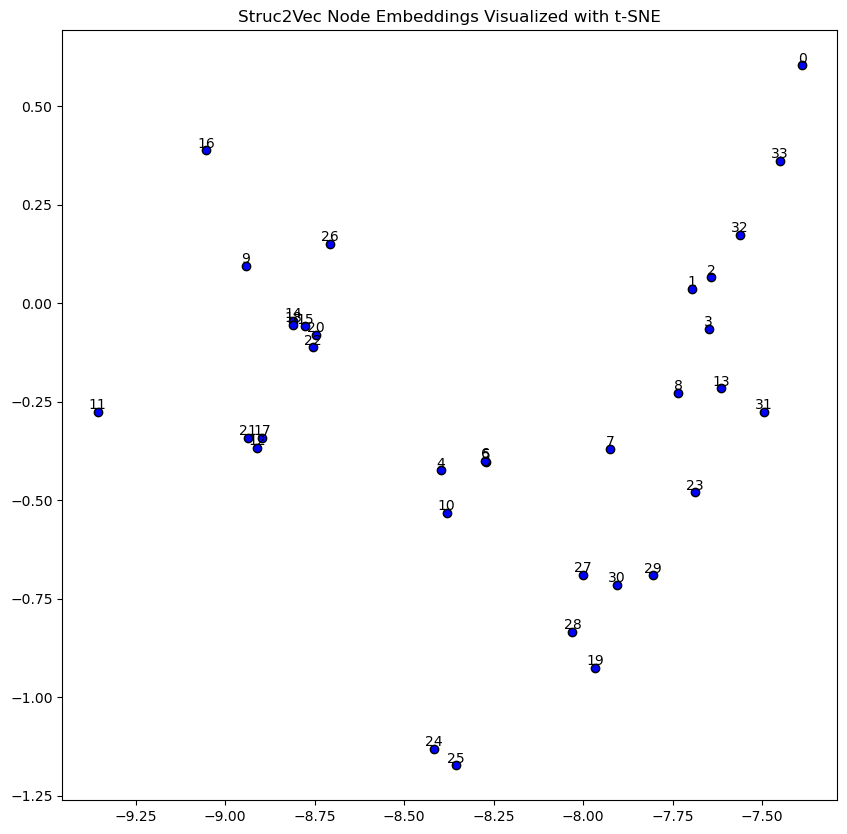

In [37]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import itertools

# Load the Karate Club graph
G = nx.karate_club_graph()

# Initialize the Struc2Vec model
model = Struc2Vec(G, walk_length=10, num_walks=100, workers=4, verbose=1)

# Train the model to get the embeddings
model.train_skipgram(embed_size=128, window_size=5)

# Get the embedding vectors
embeddings = model.get_embeddings()

# Convert embeddings to a numpy array for easier handling
nodes = list(embeddings.keys())
emb_array = np.array([embeddings[node] for node in nodes])

# Use t-SNE to reduce dimensionality to 2D
tsne = TSNE(n_components=2, random_state=42)
emb_2d = tsne.fit_transform(emb_array)

# Plot the 2D embeddings
plt.figure(figsize=(10, 10))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c='blue', edgecolors='k')

# Optionally, label the points with node identifiers
for i, node in enumerate(nodes):
    plt.annotate(node, (emb_2d[i, 0], emb_2d[i, 1]), textcoords='offset points', xytext=(0, 2), ha='center')

plt.title('Struc2Vec Node Embeddings Visualized with t-SNE')
plt.show()


# 3. Learning Role-Based Graph Embeddings (Role2Vec)

## 3.1. Create Weisfeiler-Lehman (WL) algorithm

In [1]:
import hashlib

# Weisfeiler Lehman feature extraction algorithm, which assigns features to nodes based on their structural properties and iteratively refines these features
class WeisfeilerLehmanMachine:
    """
    Weisfeiler Lehman feature extractor class.
    """
    def __init__(self, graph, features, iterations):
        """
        Initialization method which executes feature extraction.
        :param graph: The Nx graph object.
        :param features: Feature hash table.
        :param iterations: Number of WL iterations.
        """
        self.iterations = iterations
        self.graph = graph
        self.features = features
        self.nodes = self.graph.nodes()
        self.extracted_features = {k: [v] for k, v in features.items()}
        self.do_recursions()

    def do_a_recursion(self):
        """
        The method does a single WL recursion.
        :return new_features: The hash table with extracted WL features.
        """
        new_features = {}
        for node in self.nodes:
            nebs = self.graph.neighbors(node)
            degs = [self.features[str(neb)] for neb in nebs]
            features = [str(self.features[str(node)])]+sorted([str(deg) for deg in degs])
            features = "_".join(features)
            # Use a hash function (MD5) to encode the structural properties of nodes and their neighbors into feature vectors
            hash_object = hashlib.md5(features.encode())
            hashing = hash_object.hexdigest()
            new_features[str(node)] = hashing
            self.extracted_features[str(node)].append(hashing)
        return new_features

    def do_recursions(self):
        """
        The method does a series of WL recursions.
        """
        for _ in range(self.iterations):
            self.features = self.do_a_recursion()

## 3.2. Biased RandomWalk

In [2]:
import random
import numpy as np
import networkx as nx
from tqdm import tqdm

class SecondOrderRandomWalker:
    """
    Class to create second order random walks.
    """
    def __init__(self, G, p, q, num_walks, walk_length):
        """
        :param G: NetworkX object.
        :param p: Return parameter.
        :param q: In-out parameter.
        :param num_walks: Number of walks per source.
        :param walk_length: Number of nodes in walk.
        """
        self.G = G
        self.nodes = nx.nodes(self.G)
        print("Edge weighting.\n")
        for edge in tqdm(self.G.edges()):
            self.G[edge[0]][edge[1]]['weight'] = 1.0
            self.G[edge[1]][edge[0]]['weight'] = 1.0
        self.p = p
        self.q = q
        self.num_walks = num_walks
        self.walk_length = walk_length
        self.preprocess_transition_probs()
        self.simulate_walks()

    def node2vec_walk(self, start_node):
        """
        Simulate a random walk starting from start node.
        """
        G = self.G
        alias_nodes = self.alias_nodes
        alias_edges = self.alias_edges

        walk = [start_node]

        while len(walk) < self.walk_length:
            cur = walk[-1]
            cur_nbrs = sorted(G.neighbors(cur))
            if len(cur_nbrs) > 0:
                if len(walk) == 1:
                    walk.append(cur_nbrs[alias_draw(alias_nodes[cur][0], alias_nodes[cur][1])])
                else:
                    prev = walk[-2]
                    next = cur_nbrs[alias_draw(alias_edges[(prev, cur)][0], alias_edges[(prev, cur)][1])]
                    walk.append(next)
            else:
                break
        walk = [str(node) for node in walk]
        return walk

    def simulate_walks(self):
        """
        Repeatedly simulate random walks from each node.
        """
        G = self.G
        self.walks = []
        nodes = list(G.nodes())
        for iteration in range(self.num_walks):
            print("\nRandom walk round: "+str(iteration+1)+"/"+str(self.num_walks)+".\n")
            random.shuffle(nodes)
            for node in tqdm(nodes):
                self.walks.append(self.node2vec_walk(start_node=node))

    def get_alias_edge(self, src, dst):
        """
        Get the alias edge setup lists for a given edge.
        """
        G = self.G
        p = self.p
        q = self.q

        unnormalized_probs = []
        for dst_nbr in sorted(G.neighbors(dst)):
            if dst_nbr == src:
                unnormalized_probs.append(G[dst][dst_nbr]['weight']/p)
            elif G.has_edge(dst_nbr, src):
                unnormalized_probs.append(G[dst][dst_nbr]['weight'])
            else:
                unnormalized_probs.append(G[dst][dst_nbr]['weight']/q)
        norm_const = sum(unnormalized_probs)
        normalized_probs = [float(u_prob)/norm_const for u_prob in unnormalized_probs]

        return alias_setup(normalized_probs)

    def preprocess_transition_probs(self):
        """
        Preprocessing of transition probabilities for guiding the random walks.
        """
        G = self.G

        alias_nodes = {}
        print("")
        print("Preprocesing.\n")
        for node in tqdm(G.nodes()):
            unnormalized_probs = [G[node][nbr]['weight'] for nbr in sorted(G.neighbors(node))]
            norm_const = sum(unnormalized_probs)
            normalized_probs = [float(u_prob)/norm_const for u_prob in unnormalized_probs]
            alias_nodes[node] = alias_setup(normalized_probs)

        alias_edges = {}
        triads = {}

        for edge in tqdm(G.edges()):
            alias_edges[edge] = self.get_alias_edge(edge[0], edge[1])
            alias_edges[(edge[1], edge[0])] = self.get_alias_edge(edge[1], edge[0])

        self.alias_nodes = alias_nodes
        self.alias_edges = alias_edges


def alias_setup(probs):
    """
    Compute utility lists for non-uniform sampling from discrete distributions.
    Refer to https://hips.seas.harvard.edu/blog/2013/03/03/the-alias-method-efficient-sampling-with-many-discrete-outcomes/
    for details
    """
    K = len(probs)
    q = np.zeros(K)
    J = np.zeros(K, dtype=int)
    smaller = []
    larger = []

    for kk, prob in enumerate(probs):
        q[kk] = K*prob
    if q[kk] < 1.0:
        smaller.append(kk)
    else:
        larger.append(kk)

    while len(smaller) > 0 and len(larger) > 0:
        small = smaller.pop()
        large = larger.pop()

        J[small] = large
        q[large] = q[large] + q[small] - 1.0
        if q[large] < 1.0:
            smaller.append(large)
        else:
            larger.append(large)

    return J, q

def alias_draw(J, q):
    """
    Draw sample from a non-uniform discrete distribution using alias sampling.
    """
    K = len(J)

    kk = int(np.floor(np.random.rand()*K))
    if np.random.rand() < q[kk]:
        return kk
    else:
        return J[kk]


class FirstOrderRandomWalker:
    """
    Class to create first order random walks.
    """
    def __init__(self, G, num_walks, walk_length):
        """
        :param G: NetworkX graph object.
        :param num_walks: Number of walks per source node.
        :param walk_length: Number of nodes in turnctaed randonm walk.
        """
        self.G = G
        self.num_walks = num_walks
        self.walk_length = walk_length
        self.simulate_walks()

    def do_walk(self, node):
        """
        Doing a single truncated random walk from a source node.
        :param node: Source node of the truncated random walk.
        :return walk: A single random walk.
        """
        walk = [node]
        while len(walk) < self.walk_length:
            nebs = [n for n in nx.neighbors(self.G, walk[-1])]
            if len(nebs) == 0:
                break
            walk.append(random.choice(nebs))
        return walk

    def simulate_walks(self):
        """
        Doing a fixed number of truncated random walk from every node in the graph.
        """
        self.walks = []
        for iteration in range(self.num_walks):
            print("\nRandom walk round: "+str(iteration+1)+"/"+str(self.num_walks)+".\n")
            for node in tqdm(self.G.nodes()):
                walk_from_node = self.do_walk(node)
                self.walks.append(walk_from_node)

## 3.3. MotifCounterMachine 

#### Count graph motifs (small subgraphs) and orbits (specific roles within these motifs). 

#### This provides a way to capture more complex structural patterns in the graph.

In [5]:
import math
import pandas as pd
import networkx as nx
from tqdm import tqdm
from sklearn.cluster import KMeans
from scipy.sparse import csr_matrix
from sklearn.decomposition import NMF
from networkx.generators.atlas import *

# Counts the occurrences of motifs and orbits in the graph, which are small connected subgraphs
class MotifCounterMachine(object):
    """
    Motif and Orbit Counting Tool.
    """
    # Initializes the machine with the graph and parameters.
    def __init__(self, graph, args):
        """
        Initializing the object.
        :param graph: NetworkX graph.
        :param args: Arguments object.
        """
        self.graph = graph
        self.args = args

    # Generates subsets of edges to identify potential motifs.
    def create_edge_subsets(self):
        """
        Collecting nodes that form graphlets.
        """
        self.edge_subsets = dict()
        subsets = [[edge[0], edge[1]] for edge in self.graph.edges()]
        self.edge_subsets[2] = subsets
        unique_subsets = dict()
        for i in range(3, self.args.graphlet_size+1):
            for subset in tqdm(subsets):
                for node in subset:
                    for neb in self.graph.neighbors(node):
                        new_subset = subset+[neb]
                        if len(set(new_subset)) == i:
                            new_subset.sort()
                            unique_subsets[tuple(new_subset)] = 1
            subsets = [list(k) for k, v in unique_subsets.items()]
            self.edge_subsets[i] = subsets
            unique_subsets = dict()

    # Enumerates different graphlets and assigns unique categories to motifs and orbits
    def enumerate_graphs(self):
        """
        Enumerating connected benchmark graphlets.
        """
        graphs = graph_atlas_g()
        self.interesting_graphs = {i: [] for i in range(2, self.args.graphlet_size+1)}
        for graph in graphs:
            if graph.number_of_nodes() > 1 and  graph.number_of_nodes() < self.args.graphlet_size+1:
                if nx.is_connected(graph):
                    self.interesting_graphs[graph.number_of_nodes()].append(graph)

    # Maps different motifs and orbits to unique categories
    def enumerate_categories(self):
        """
        Enumerating orbits in graphlets.
        """
        main_index = 0
        self.categories = dict()
        for size, graphs in self.interesting_graphs.items():
            self.categories[size] = dict()
            for index, graph in enumerate(graphs):
                self.categories[size][index] = dict()
                degrees = list(set([graph.degree(node) for node in graph.nodes()]))
                for degree in degrees:
                    self.categories[size][index][degree] = main_index
                    main_index = main_index + 1
        self.unique_motif_count = main_index + 1

    # Counts the occurrences of each motif/orbit for every node in the graph
    def setup_features(self):
        """
        Calculating the graphlet orbit counts.
        """
        self.features = {n: {i: 0 for i in range(self.unique_motif_count)} for n in self.graph.nodes()}
        for size, node_lists in self.edge_subsets.items():
            graphs = self.interesting_graphs[size]
            for nodes in tqdm(node_lists):
                sub_gr = self.graph.subgraph(nodes)
                for index, graph in enumerate(graphs):
                    if nx.is_isomorphic(sub_gr, graph):
                        for node in sub_gr.nodes():
                            self.features[node][self.categories[size][index][sub_gr.degree(node)]] += 1
                        break

    # Creates a tabular representation of motif counts, which can be further processed or binned
    def create_tabular_motifs(self):
        """
        Creating tabular motifs for factorization.
        """
        self.binned_features = {node: [] for node in self.graph.nodes()}
        self.motifs = [[node]+[self.features[node][index] for index in  range(self.unique_motif_count )] for node in self.graph.nodes()]
        self.motifs = pd.DataFrame(self.motifs)
        self.motifs.columns = ["id"] + ["role_"+str(index) for index in range(self.unique_motif_count)]
        for index in range(self.unique_motif_count):
            features = self.motifs["role_"+str(index)].values.tolist()
            if sum(features) > 0:
                features = [math.log(feature+1) for feature in features]
                features = pd.qcut(features, self.args.quantiles, duplicates="drop", labels=False)
                for node in self.graph.nodes():
                    self.binned_features[node].append(str(int(index*self.args.quantiles + features[node])))
    
    # Create node features either by concatenating quantile bin labels or by factorizing the feature matrix to reduce dimensionality.
    def join_strings(self):
        """
        Creating string labels by joining the individual quantile labels.
        """
        return {str(node): ["_".join(self.binned_features[node])] for node in self.graph.nodes()}

    def factorize_string_matrix(self):
        """
        Creating string labels by factorization.
        """
        rows = [node for node, features in self.binned_features.items() for feature in features]
        columns = [int(feature) for node, features in self.binned_features.items() for feature in features]
        scores = [1 for i in range(len(columns))]
        row_number = max(rows)+1
        column_number = max(columns)+1
        features = csr_matrix((scores, (rows, columns)), shape=(row_number, column_number))
        model = NMF(n_components=self.args.factors, init="random", random_state=self.args.seed, alpha=self.args.beta)
        factors = model.fit_transform(features)
        kmeans = KMeans(n_clusters=self.args.clusters, random_state=self.args.seed).fit(factors)
        labels = kmeans.labels_
        features = {str(node): str(labels[node]) for node in self.graph.nodes()}
        return features

    # Executes the entire motif counting and feature creation process.
    def create_string_labels(self):
        """
        Executing the whole label creation mechanism.
        """
        self.create_edge_subsets()
        self.enumerate_graphs()
        self.enumerate_categories()
        self.setup_features()
        self.create_tabular_motifs()
        if self.args.motif_compression == "string":
            features = self.join_strings()
        else:
            features = self.factorize_string_matrix()
        return features

## 3.4. Create Role2Vec

In [8]:
import math
import numpy as np
import pandas as pd
import networkx as nx
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

# The Role2Vec model class, which combines structural feature extraction with random walks and node embeddings
class Role2Vec:
    """
    Role2Vec model class.
    """
    # Initializes the model with given parameters and a given graph
    def __init__(self, args):
        """
        Role2Vec machine constructor.
        :param args: Arguments object with the model hyperparameters.
        """
        self.args = args
        self.graph = nx.karate_club_graph()
    
    # Performs random walks on the graph to capture the local structure around each node. 
    # Depending on the sampling method specified, it can perform first-order or second-order random walks
    def do_walks(self):
        """
        Doing first/second order random walks.
        """
        if self.args['sampling'] == "second":
            self.sampler = SecondOrderRandomWalker(self.graph, self.args['P'], self.args['Q'],
                                                   self.args['walk_number'], self.args['walk_length'])
        else:
            self.sampler = FirstOrderRandomWalker(self.graph, self.args['walk_number'], self.args['walk_length'])
        self.walks = self.sampler.walks
        del self.sampler

    # Extracts structural features for nodes using different methods (Weisfeiler-Lehman features, degree features, or motif features)
    def create_structural_features(self):
        """
        Extracting structural features.
        """
        if self.args['features'] == "wl":
            features = {str(node): str(int(math.log(self.graph.degree(node)+1, self.args['log_base']))) for node in self.graph.nodes()}
            machine = WeisfeilerLehmanMachine(self.graph, features, self.args['labeling_iterations'])
            machine.do_recursions()
            self.features = machine.extracted_features
        elif self.args['features'] == "degree":
            self.features = {str(node): [str(self.graph.degree(node))] for node in self.graph.nodes()}
        else:
            machine = MotifCounterMachine(self.graph, self.args)
            self.features = machine.create_string_labels()

    # Combines the structural features with the random walks to create a context for each node, aggregating features from nodes encountered during the walks.
    def create_pooled_features(self):
        """
        Pooling the features with the walks
        """
        features = {str(node):[] for node in self.graph.nodes()}
        for walk in self.walks:
            for node_index in range(self.args['walk_length']-self.args['window_size']):
                for j in range(1, self.args['window_size']+1):
                    features[str(walk[node_index])].append(self.features[str(walk[node_index+j])])
                    features[str(walk[node_index+j])].append(self.features[str(walk[node_index])])

        for node, feature_set in features.items():
            features[node] = [feature for feature_elems in feature_set for feature in feature_elems]
        return features
    # Uses TF-IDF vectorization to learn embeddings from the pooled features.
    # Converts node features into TF-IDF weighted vectors based on feature importance
    def create_embedding(self):
        """
        Fitting an embedding using TF-IDF vectorization.
        """
        # Convert features to text format (join as strings)
        feature_texts = {}
        for node, feature_list in self.pooled_features.items():
            feature_texts[node] = ' '.join([str(f) for f in feature_list])
        
        # Create TF-IDF vectorizer
        vectorizer = TfidfVectorizer(
            max_features=self.args['dimensions'],
            lowercase=False,
            norm='l2'
        )
        
        # Get nodes in sorted order
        nodes = sorted([int(n) for n in self.graph.nodes()])
        texts = [feature_texts[str(node)] for node in nodes]
        
        # Fit and transform to get TF-IDF vectors
        tfidf_matrix = vectorizer.fit_transform(texts)
        
        # Convert sparse matrix to dense array
        embedding = tfidf_matrix.toarray()
        return embedding

    # Combines the steps of pooling features and learning embeddings into a single process.
    def learn_embedding(self):
        """
        Pooling the features and learning an embedding.
        """
        self.pooled_features = self.create_pooled_features()
        self.embedding = self.create_embedding()
    # Saves the learned node embeddings to a CSV file for later use
    def save_embedding(self):
        """
        Function to save the embedding.
        """
        columns = ["id"] + ["x_"+str(x) for x in range(self.embedding.shape[1])]
        ids = np.array([node for node in self.graph.nodes()]).reshape(-1, 1)
        embedding = pd.DataFrame(np.concatenate([ids, self.embedding], axis=1), columns=columns)
        embedding = embedding.sort_values(by=['id'])
        embedding.to_csv(self.args['output'], index=None)

## 3.5. Train Role2Vec

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

# Load the Karate Club network
karate_club = nx.karate_club_graph()

# Define hyperparameters
args = {
    "output": "karate_club_embeddings.csv",
    "dimensions": 128,
    "walk_number": 10,
    "walk_length": 80,
    "window_size": 10,
    "sampling": "second",
    "features": "degree",
    "labeling_iterations": 2,
    "P": 1.0,
    "Q": 1.0,
    "log_base": 2,
    "min_count": 1,
    "alpha": 0.025,
    "min_alpha": 0.00025,
    "down_sampling": 0.001,
    "workers": 4,
    "epochs": 20
}

# Create and run Role2Vec model
role2vec = Role2Vec(args)
role2vec.graph = karate_club  # Set the graph directly
role2vec.do_walks()
role2vec.create_structural_features()
role2vec.learn_embedding()
role2vec.save_embedding()


Edge weighting.



100%|██████████| 78/78 [00:00<00:00, 207982.02it/s]


Edge weighting.



100%|██████████| 78/78 [00:00<00:00, 207982.02it/s]



Preprocesing.



...

100%|██████████| 34/34 [00:00<00:00, 3445.76it/s]



Random walk round: 9/10.



100%|██████████| 34/34 [00:00<00:00, 2599.13it/s]



Random walk round: 10/10.



100%|██████████| 34/34 [00:00<00:00, 2720.56it/s]


## 3.6. Visualize Role2Vec

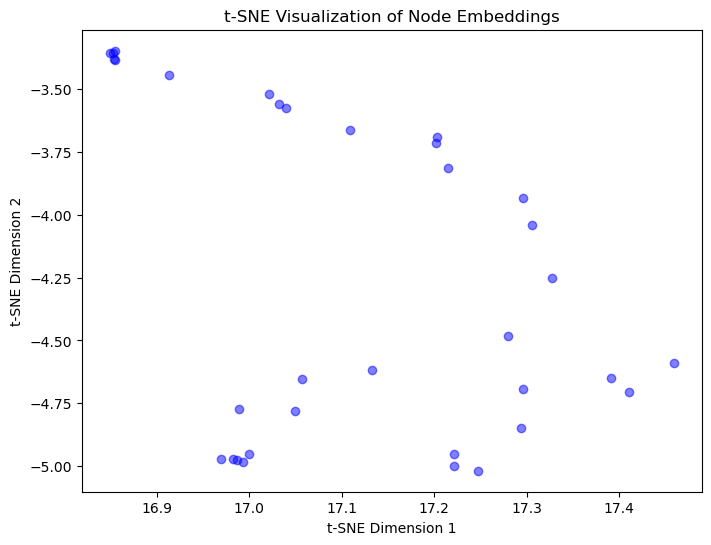

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Load the embedding CSV file
embedding_df = pd.read_csv("karate_club_embeddings.csv")

# Extract the embedding vectors
embedding_vectors = embedding_df.iloc[:, 1:].values

# Perform dimensionality reduction using t-SNE
tsne = TSNE(n_components=2, random_state=42)
embedding_tsne = tsne.fit_transform(embedding_vectors)

# Plot the embeddings
plt.figure(figsize=(8, 6))
plt.scatter(embedding_tsne[:, 0], embedding_tsne[:, 1], c='b', alpha=0.5)
plt.title("t-SNE Visualization of Node Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()


# 4. Learning Structural Node Embeddings via Diffusion Wavelets (GraphWave)

## 4.1. Helper class

In [77]:
import warnings
from typing import List
import re
import random
import numpy as np
import networkx as nx
from tqdm.auto import trange


class Estimator(object):
    """Estimator base class with constructor and public methods."""

    seed: int

    def __init__(self):
        """Creating an estimator."""

    def fit(self):
        """Fitting a model."""

    def get_embedding(self):
        """Getting the embeddings (graph or node level)."""

    def get_memberships(self):
        """Getting the membership dictionary."""

    def get_cluster_centers(self):
        """Getting the cluster centers."""

    def get_params(self):
        """Get parameter dictionary for this estimator."""
        rx = re.compile(r"^\_")
        params = self.__dict__
        params = {key: params[key] for key in params if not rx.search(key)}
        return params

    def set_params(self, **parameters):
        """Set the parameters of this estimator."""
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

    def _set_seed(self):
        """Creating the initial random seed."""
        random.seed(self.seed)
        np.random.seed(self.seed)

    @staticmethod
    def _ensure_walk_traversal_conditions(
        graph: nx.classes.graph.Graph,
    ) -> nx.classes.graph.Graph:
        """Ensure walk traversal conditions (adds self-loops if missing)."""
        for node_index in trange(
            graph.number_of_nodes(),
            leave=False,
            disable=graph.number_of_nodes() < 10_000,
            desc="Checking main diagonal existance",
            dynamic_ncols=True,
        ):
            if not graph.has_edge(node_index, node_index):
                warnings.warn(
                    "Please do be advised that "
                    "the graph you have provided does not "
                    "contain (some) edges in the main "
                    "diagonal, for instance the self-loop "
                    f"constitued of ({node_index}, {node_index}). These selfloops "
                    "are necessary to ensure that the graph "
                    "is traversable, and for this reason we "
                    "create a copy of the graph and add therein "
                    "the missing edges. Since we are creating "
                    "a copy, this will immediately duplicate "
                    "the memory requirements. To avoid this double "
                    "allocation, you can provide the graph with the selfloops."
                )
                # Create a copy and add self-loops
                graph = graph.copy()
                graph.add_edges_from(
                    (
                        (index, index)
                        for index in range(graph.number_of_nodes())
                        if not graph.has_edge(index, index)
                    )
                )
                break

        return graph

    @staticmethod
    def _check_indexing(graph: nx.classes.graph.Graph):
        """Checking the consecutive numeric indexing (0, 1, 2, ..., n-1)."""
        numeric_indices = [index for index in range(graph.number_of_nodes())]
        node_indices = sorted([node for node in graph.nodes()])

        assert numeric_indices == node_indices, "The node indexing is wrong."

    def _check_graph(self, graph: nx.classes.graph.Graph) -> nx.classes.graph.Graph:
        """Check the Karate Club assumptions about the graph."""
        self._check_indexing(graph)
        graph = self._ensure_walk_traversal_conditions(graph)

        return graph

    def _check_graphs(self, graphs: List[nx.classes.graph.Graph]):
        """Check the Karate Club assumptions for a list of graphs."""
        graphs = [self._check_graph(graph) for graph in graphs]

        return graphs

## 4.2. GraphWave

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pygsp

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
%matplotlib inline

class GraphWave(Estimator):
  
    def __init__(self, 
                 sample_number: int = 200,
                 step_size: float = 0.1,
                 heat_coefficient: float = 1.0,
                 approximation: int = 50,
                 mechanism: str = "approximate",
                 switch: int = 1000,
                 seed: int = 42):
        
        self.sample_number = sample_number
        self.step_size = step_size
        self.heat_coefficient = heat_coefficient
        self.approximation = approximation
        self.mechanism = mechanism
        self.switch = switch
        self.seed = seed
        np.random.seed(seed)
    
    def _create_evaluation_points(self):
        """Create grid points for the characteristic function."""
        self._steps = np.arange(0, self.sample_number) * self.step_size
    
    def _add_self_loops(self, graph: nx.Graph) -> nx.Graph:
        """Add self-loops to avoid KarateClub and PyGSP warnings."""
        G = graph.copy()
        for node in G.nodes():
            if not G.has_edge(node, node):
                G.add_edge(node, node, weight=1.0)
        return G
    
    def fit(self, graph: nx.Graph):
        """Fit the GraphWave model."""
        self._set_seed()
        
        # Pre-process graph to avoid warnings
        graph = self._check_graph(graph)           
        graph = self._add_self_loops(graph)        
        
        self._create_evaluation_points()
        
        # Convert to PyGSP
        A = nx.adjacency_matrix(graph)
        self._G = pygsp.graphs.Graph(A)
        self._number_of_nodes = graph.number_of_nodes()
        
        # Choose method
        if self._number_of_nodes > self.switch or self.mechanism == "approximate":
            self._approximate_embedding()
        else:
            self._exact_embedding()
        
        return self
    
    def _exact_embedding(self):
        """Exact method using eigenvalue decomposition."""
        self._G.compute_fourier_basis()
        eigenvalues = self._G.e / max(self._G.e)
        U = self._G.U
        
        embeddings = []
        for node in range(self._number_of_nodes):
            impulse = np.zeros(self._number_of_nodes)
            impulse[node] = 1.0
            
            heat = np.exp(-self.heat_coefficient * eigenvalues)
            wave = U @ np.diag(heat) @ U.T @ impulse
            
            char_func = [np.mean(np.exp(1j * step * wave)) for step in self._steps]
            embeddings.append(char_func)
        
        self._embedding = np.array(embeddings)
    
    def _approximate_embedding(self):
        """Approximate method using Chebyshev polynomials."""
        self._G.estimate_lmax()
        
        heat_filter = pygsp.filters.Heat(self._G, scale=self.heat_coefficient)
        
        cheby = pygsp.filters.approximations.compute_cheby_coeff(
            heat_filter, m=self.approximation
        )
        
        embeddings = []
        for node in range(self._number_of_nodes):
            impulse = np.zeros(self._number_of_nodes)
            impulse[node] = 1.0
            
            wave = pygsp.filters.approximations.cheby_op(self._G, cheby, impulse)
            char_func = [np.mean(np.exp(1j * step * wave)) for step in self._steps]
            embeddings.append(char_func)
        
        self._embedding = np.array(embeddings)
    
    def get_embedding(self) -> np.ndarray:
        """Return embedding: real + imaginary parts concatenated."""
        real = self._embedding.real
        imag = self._embedding.imag
        return np.hstack([real, imag])
    
    def get_embedding_2d(self, method='pca'):
        """Reduce embedding to 2D for visualization."""
        emb = self.get_embedding()
        if method.lower() == 'pca':
            reducer = PCA(n_components=2, random_state=self.seed)
        else:
            reducer = TSNE(n_components=2, random_state=self.seed)
        return reducer.fit_transform(emb)

## 4.3. Test on Karate Club dataset

In [72]:
G = nx.karate_club_graph()

model = GraphWave(
    sample_number=100,
    step_size=0.1,
    heat_coefficient=1.0,
    approximation=50,
    mechanism="approximate"
)

model.fit(G)
embedding = model.get_embedding()

print(f"Embedding shape : {embedding.shape}")
print(f"Number of nodes : {G.number_of_nodes()}")

/tmp/ipykernel_15557/1448795865.py:63: UserWarning: Please do be advised that the graph you have provided does not contain (some) edges in the main diagonal, for instance the self-loop constitued of (0, 0). These selfloops are necessary to ensure that the graph is traversable, and for this reason we create a copy of the graph and add therein the missing edges. Since we are creating a copy, this will immediately duplicate the memory requirements. To avoid this double allocation, you can provide the graph with the selfloops.
  warnings.warn(
2026-05-19 16:57:38,727:[WARNING](pygsp.graphs.graph.__init__): Adjacency: there are self-loops (non-zeros on the diagonal). The Laplacian will not see them.


Embedding shape : (34, 200)
Number of nodes : 34


## 4.4. Visualization

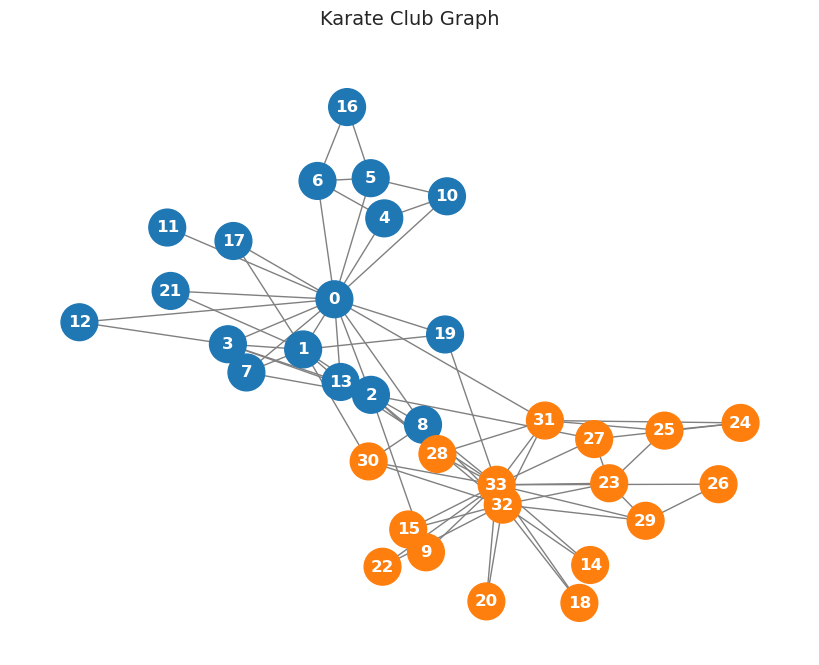

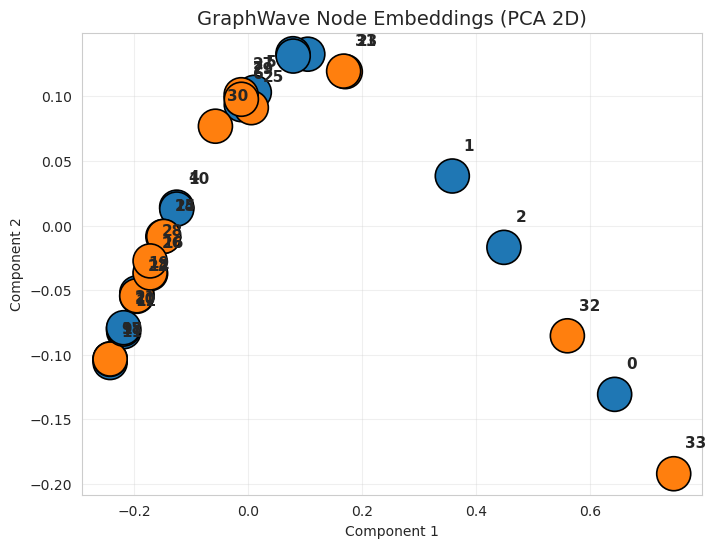

In [76]:
import matplotlib.pyplot as plt
import networkx as nx

# Color community
G = nx.karate_club_graph()
colors = ['#1f77b4' if G.nodes[n]['club'] == 'Mr. Hi' else '#ff7f0e' 
          for n in G.nodes()]

# Embedding 2D
emb_2d = model.get_embedding_2d(method='pca')

# Original Graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, 
        node_color=colors, 
        node_size=700, 
        with_labels=True,
        font_color='white', 
        font_weight='bold',
        edge_color='gray')

plt.title("Karate Club Graph\n", fontsize=14)
plt.show()

# GraphWave Embedding 
plt.figure(figsize=(8, 6))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], 
            c=colors, 
            s=600, 
            edgecolors='black', 
            linewidth=1.2)

plt.title("GraphWave Node Embeddings (PCA 2D)", fontsize=14)
plt.xlabel("Component 1")
plt.ylabel("Component 2")

for i in range(len(emb_2d)):
    plt.annotate(str(i), 
                 (emb_2d[i, 0] + 0.02, emb_2d[i, 1] + 0.02),
                 fontsize=11, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.show()